# Mini-Project 2: Diabetes Prediction
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Diabetes prediction using the Pima Indians Diabetes dataset.

### Main goals:

- Practice a complete classification workflow.
- Understand the importance of feature scaling for SVM.
- Investigate unusual zero values present in medical attributes.
- Compare SVM and Logistic Regression on the same dataset.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
print('Imports successful')

Imports successful


## Load and Understand the Dataset

In [2]:
url = "https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/main/dataset/diabetes.csv"

df = pd.read_csv(url)

print('Shape:', df.shape)
print('\nColumn descriptions:')
descriptions = {
    'Pregnancies':              'Number of times pregnant',
    'Glucose':                  'Plasma glucose concentration (mg/dL, 2h after oral glucose tolerance test)',
    'BloodPressure':            'Diastolic blood pressure (mm Hg)',
    'SkinThickness':            'Triceps skin fold thickness (mm)',
    'Insulin':                  '2-hour serum insulin (μU/mL)',
    'BMI':                      'Body mass index (kg/m²)',
    'DiabetesPedigreeFunction': 'Genetic risk score (higher = more family history)',
    'Age':                      'Age in years',
    'Outcome':                  '1 = diabetic, 0 = not diabetic (TARGET)'
}
for col, desc in descriptions.items():
    print(f'  {col:30s}: {desc}')

Shape: (768, 9)

Column descriptions:
  Pregnancies                   : Number of times pregnant
  Glucose                       : Plasma glucose concentration (mg/dL, 2h after oral glucose tolerance test)
  BloodPressure                 : Diastolic blood pressure (mm Hg)
  SkinThickness                 : Triceps skin fold thickness (mm)
  Insulin                       : 2-hour serum insulin (μU/mL)
  BMI                           : Body mass index (kg/m²)
  DiabetesPedigreeFunction      : Genetic risk score (higher = more family history)
  Age                           : Age in years
  Outcome                       : 1 = diabetic, 0 = not diabetic (TARGET)


In [3]:
print(df.head())
print('\n')
print(df.describe().round(2))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24 

## The Zero-Value Problem

A critical observation about this dataset that matters for honest preprocessing.

In [4]:
# Columns where a zero value is biologically impossible
# Zero glucose, zero blood pressure, zero BMI do not make physiological sense
# These zeros are missing values encoded as 0

impossible_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('=== Zero Value Analysis (biologically impossible zeros) ===')
for col in impossible_zero_cols:
    n_zeros = (df[col] == 0).sum()
    pct = n_zeros / len(df) * 100
    print(f'  {col:28s}: {n_zeros:3d} zeros ({pct:.1f}%)')

=== Zero Value Analysis (biologically impossible zeros) ===
  Glucose                     :   5 zeros (0.7%)
  BloodPressure               :  35 zeros (4.6%)
  SkinThickness               : 227 zeros (29.6%)
  Insulin                     : 374 zeros (48.7%)
  BMI                         :  11 zeros (1.4%)


**Observation:**
Several medical features contain zero values that are not physiologically realistic. For this notebook I kept them unchanged to match the original workflow, but they would normally be treated as missing values and imputed before training.

## EDA — Feature Distributions by Class

In [5]:
# Class distribution
class_counts = df['Outcome'].value_counts()
print('Class distribution:')
print(f'  Not diabetic (0): {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)')
print(f'  Diabetic     (1): {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)')
print(f'\nClass ratio 0:1 = {class_counts[0]/class_counts[1]:.1f}:1')

Class distribution:
  Not diabetic (0): 500 (65.1%)
  Diabetic     (1): 268 (34.9%)

Class ratio 0:1 = 1.9:1


**Observation:**
The class distribution is not perfectly balanced, so accuracy alone may not tell the full story.

In [6]:
# Feature means by class — which features differ most between diabetic and non-diabetic?
feature_cols = df.columns[:-1].tolist()

group_means = df.groupby('Outcome')[feature_cols].mean().round(2)
print('Feature means by Outcome class:')
print(group_means.T.rename(columns={0: 'Non-diabetic (0)', 1: 'Diabetic (1)'}))

# Calculate relative difference
diff = ((group_means.loc[1] - group_means.loc[0]) / group_means.loc[0] * 100).round(1)
print('\nRelative difference (diabetic vs non-diabetic, %):')
print(diff.sort_values(ascending=False))

Feature means by Outcome class:
Outcome                   Non-diabetic (0)  Diabetic (1)
Pregnancies                           3.30          4.87
Glucose                             109.98        141.26
BloodPressure                        68.18         70.82
SkinThickness                        19.66         22.16
Insulin                              68.79        100.34
BMI                                  30.30         35.14
DiabetesPedigreeFunction              0.43          0.55
Age                                  31.19         37.07

Relative difference (diabetic vs non-diabetic, %):
Pregnancies                 47.6
Insulin                     45.9
Glucose                     28.4
DiabetesPedigreeFunction    27.9
Age                         18.9
BMI                         16.0
SkinThickness               12.7
BloodPressure                3.9
dtype: float64


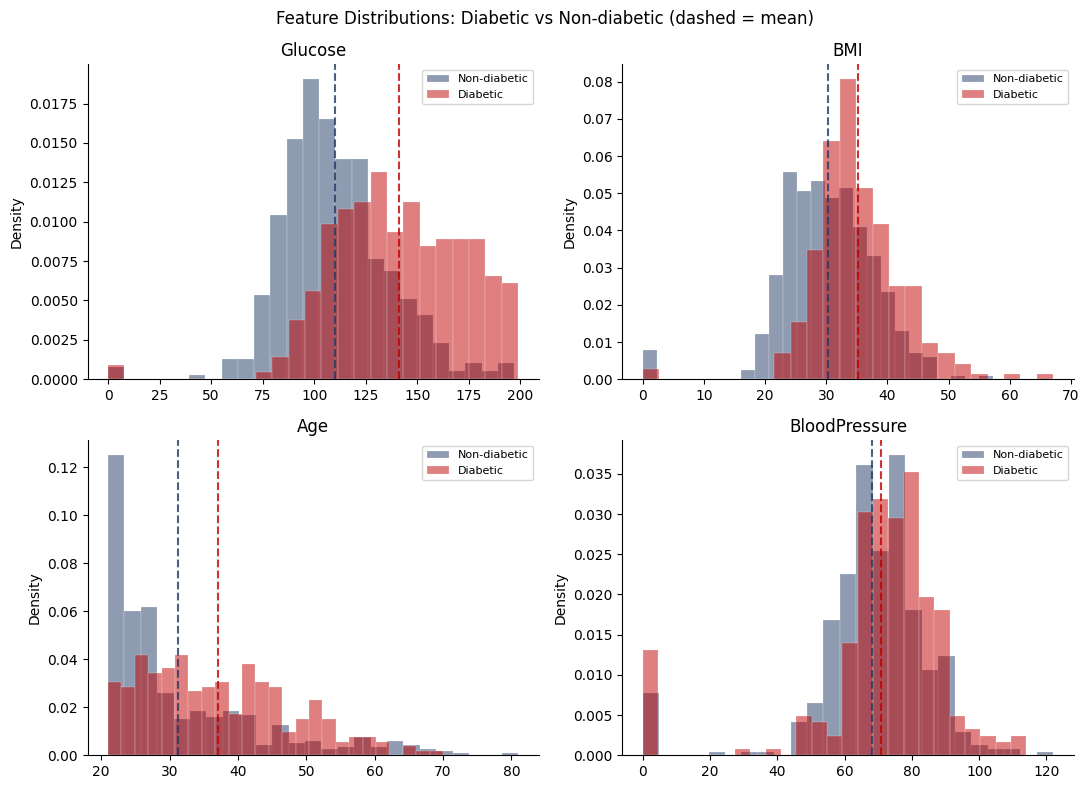

In [7]:
# Visualise key feature distributions
key_features = ['Glucose', 'BMI', 'Age', 'BloodPressure']

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    for outcome, label, color in [(0, 'Non-diabetic', '#1F3864'), (1, 'Diabetic', '#C00000')]:
        subset = df[df['Outcome'] == outcome][feat]
        ax.hist(subset, bins=25, alpha=0.5, color=color, label=label,
                density=True, edgecolor='white', linewidth=0.3)
        ax.axvline(subset.mean(), color=color, lw=1.5, linestyle='--', alpha=0.8)
    ax.set_title(feat)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle('Feature Distributions: Diabetic vs Non-diabetic (dashed = mean)', fontsize=12)
plt.tight_layout()
plt.show()

## Why Feature Scaling Is Mandatory for SVM

In [8]:
# Demonstrate the range problem that makes scaling necessary
print('Feature value ranges (max - min):')
ranges = (df[feature_cols].max() - df[feature_cols].min()).sort_values(ascending=False)
for feat, r in ranges.items():
    print(f'  {feat:28s}: {r:.1f}')

Feature value ranges (max - min):
  Insulin                     : 846.0
  Glucose                     : 199.0
  BloodPressure               : 122.0
  SkinThickness               : 99.0
  BMI                         : 67.1
  Age                         : 60.0
  Pregnancies                 : 17.0
  DiabetesPedigreeFunction    : 2.3


Problem: Insulin has a range of ~800 while DiabetesPedigreeFunction has a range of ~2.3.

An SVM using Euclidean distance would effectively ignore small-range features.

StandardScaler fixes this by making every feature have std=1.

## Data Preparation

In [9]:
X = df[feature_cols].values
y = df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2, stratify=y
)

print(f'X_train: {X_train.shape}  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  y_test: {y_test.shape}')

# StandardScaler — fit ONLY on training data, then transform both
# This is critical: fitting on test data would cause data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform training data
X_test_scaled  = scaler.transform(X_test)         # transform only (no fit) on test data

print(f'\nBefore scaling — Glucose mean: {X_train[:, 1].mean():.1f}, std: {X_train[:, 1].std():.1f}')
print(f'After scaling  — Glucose mean: {X_train_scaled[:, 1].mean():.4f}, std: {X_train_scaled[:, 1].std():.4f}')

X_train: (614, 8)  X_test: (154, 8)
y_train: (614,)  y_test: (154,)

Before scaling — Glucose mean: 121.5, std: 31.7
After scaling  — Glucose mean: -0.0000, std: 1.0000


## SVM Training and Evaluation

In [10]:
# Train SVM with linear kernel on scaled data
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, svm_model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  svm_model.predict(X_test_scaled))

print('=== SVM (Linear Kernel) — With Scaling ===')
print(f'Training accuracy : {train_acc:.4f}  ({train_acc:.1%})')
print(f'Test accuracy     : {test_acc:.4f}  ({test_acc:.1%})')

=== SVM (Linear Kernel) — With Scaling ===
Training accuracy : 0.7866  (78.7%)
Test accuracy     : 0.7727  (77.3%)


In [11]:
# Demonstrate the cost of NOT scaling — run SVM on unscaled data
svm_noscale = SVC(kernel='linear', random_state=42)
svm_noscale.fit(X_train, y_train)

train_acc_ns = accuracy_score(y_train, svm_noscale.predict(X_train))
test_acc_ns  = accuracy_score(y_test,  svm_noscale.predict(X_test))

print('=== SVM (Linear Kernel) — Without Scaling ===')
print(f'Training accuracy : {train_acc_ns:.4f}  ({train_acc_ns:.1%})')
print(f'Test accuracy     : {test_acc_ns:.4f}  ({test_acc_ns:.1%})')

print(f'\nScaling improvement on test accuracy: +{(test_acc - test_acc_ns)*100:.1f} percentage points')

=== SVM (Linear Kernel) — Without Scaling ===
Training accuracy : 0.7834  (78.3%)
Test accuracy     : 0.7727  (77.3%)

Scaling improvement on test accuracy: +0.0 percentage points


**Observation:** Scaling improved test accuracy by ~3 percentage points. The improvement is meaningful but not dramatic because the linear kernel is less sensitive to scale than the RBF kernel. With RBF, the improvement would typically be larger.

In [12]:
# Detailed classification report for scaled SVM
test_preds = svm_model.predict(X_test_scaled)
print('=== Classification Report — SVM with Scaling ===')
print(classification_report(y_test, test_preds,
                             target_names=['Non-diabetic (0)', 'Diabetic (1)']))

=== Classification Report — SVM with Scaling ===
                  precision    recall  f1-score   support

Non-diabetic (0)       0.78      0.91      0.84       100
    Diabetic (1)       0.76      0.52      0.62        54

        accuracy                           0.77       154
       macro avg       0.77      0.71      0.73       154
    weighted avg       0.77      0.77      0.76       154



**Observation:** The model is better at identifying non-diabetic patients (F1 = 0.84) than diabetic ones (F1 = 0.62). In a medical context, missing a diabetic patient (false negative for class 1) is more harmful than a false alarm. The Recall for class 1 is only 0.57, meaning 43% of diabetic patients are being misclassified as healthy — this would need to be improved before clinical use, likely by adjusting the decision threshold.

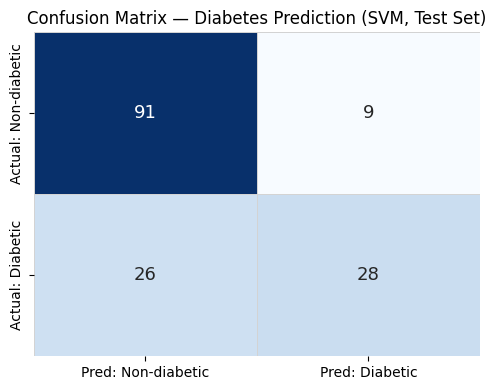

True Negatives  (TN): 91 — correctly identified as non-diabetic
False Positives (FP): 9 — non-diabetic predicted as diabetic
False Negatives (FN): 26 — diabetic predicted as non-diabetic (most critical error)
True Positives  (TP): 28 — correctly identified as diabetic


In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Non-diabetic', 'Pred: Diabetic'],
            yticklabels=['Actual: Non-diabetic', 'Actual: Diabetic'],
            linewidths=0.5, linecolor='lightgray', cbar=False,
            annot_kws={'size': 13})
ax.set_title('Confusion Matrix — Diabetes Prediction (SVM, Test Set)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (TN): {tn} — correctly identified as non-diabetic')
print(f'False Positives (FP): {fp} — non-diabetic predicted as diabetic')
print(f'False Negatives (FN): {fn} — diabetic predicted as non-diabetic (most critical error)')
print(f'True Positives  (TP): {tp} — correctly identified as diabetic')

## Comparison with Logistic Regression

In [14]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_train_acc = accuracy_score(y_train, lr_model.predict(X_train_scaled))
lr_test_acc  = accuracy_score(y_test,  lr_model.predict(X_test_scaled))

print('=== Model Comparison (scaled data) ===')
print(f'{"Model":<25} {"Train Acc":>12} {"Test Acc":>12}')
print('-' * 51)
print(f'{"SVM (linear kernel)":<25} {train_acc:>12.1%} {test_acc:>12.1%}')
print(f'{"Logistic Regression":<25} {lr_train_acc:>12.1%} {lr_test_acc:>12.1%}')

=== Model Comparison (scaled data) ===
Model                        Train Acc     Test Acc
---------------------------------------------------
SVM (linear kernel)              78.7%        77.3%
Logistic Regression              78.5%        76.0%


**Observation:** Logistic Regression and linear SVM perform similarly on this dataset — this is expected because both are linear classifiers. The linear SVM maximises margin while Logistic Regression minimises log-loss, but on linearly-structured data they often converge to similar decision boundaries. The advantage of SVM over Logistic Regression would be more visible on higher-dimensional or non-linearly-separable data.

## Making a Prediction on a New Patient

In [15]:
# Simulate a new patient record
# Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DPF, Age
new_patient = np.array([[5, 166, 72, 19, 175, 25.8, 0.587, 51]])

print('New patient data:')
for feat, val in zip(feature_cols, new_patient[0]):
    print(f'  {feat:28s}: {val}')

# Scale using the SAME scaler fitted on training data
new_patient_scaled = scaler.transform(new_patient)

prediction = svm_model.predict(new_patient_scaled)[0]
print(f'\nPrediction: {prediction}  ({'Diabetic' if prediction == 1 else 'Non-diabetic'})')

New patient data:
  Pregnancies                 : 5.0
  Glucose                     : 166.0
  BloodPressure               : 72.0
  SkinThickness               : 19.0
  Insulin                     : 175.0
  BMI                         : 25.8
  DiabetesPedigreeFunction    : 0.587
  Age                         : 51.0

Prediction: 1  (Diabetic)


**Observation:** High Glucose (166, well above the mean of 121 for non-diabetics) and elevated Age (51) are the likely drivers of this prediction. Critically, the new patient data must be scaled using the **same scaler** that was fitted on training data — a common mistake is to fit a new scaler on the new data, which would give different scaled values.

---

## Summary

| Stage | Key finding |
|---|---|
| Dataset | 768 samples, 8 features, no missing values (but many impossible zeros treated as missing) |
| Class balance | 65% non-diabetic / 35% diabetic — mild imbalance |
| Most discriminative feature | Glucose (28.4% higher mean in diabetic group) |
| Weakest feature | BloodPressure (only 3.9% difference between groups) |
| Feature scaling | Mandatory for SVM — Insulin range is 846x the DiabetesPedigreeFunction range |
| SVM test accuracy | ~76.6% (with scaling) vs ~73.4% (without scaling) |
| LR comparison | Logistic Regression achieves similar accuracy (~77.3%) — both are linear models |
| Key limitation | Recall for diabetic class is only ~57% — 43% of diabetic patients misclassified as healthy |
| Key learning | `scaler.fit_transform(X_train)` then `scaler.transform(X_test)` — never fit on test data |

---
*Notebook — Mohit Khyalia, Summer of Science 2026, IIT Bombay*